# k平均法クラスタリング(PROC FASTCLUS)による加入者利用量セグメントの発見


## エグゼクティブサマリー

ある通信アナリティクスチームは、月間モバイルデータ消費量という単一のラベルなし列から出発し、そこに明確な顧客ティアが隠れているかを知りたいと考えている。**PROC FASTCLUS**（非階層*k*平均法クラスタ分析）を使い、チームはログ利用量で加入者をクラスタリングし、FASTCLUSが実際に報告する基準に基づいて2・3・4セグメントの解を比較し、3セグメントの分割を採用する。今回の実行では、発見された3つのセグメントはそれぞれ月間平均利用量**3.1GB**、**12.8GB**、**45.4GB**、加入者数**49**、**34**、**17**人となり、明快なライト/ミディアム/ヘビーの構造が現れている。発見されたラベルを、ホールドアウトした生成時のラベルと突き合わせると、**100人中96人**の加入者が正しく回収されている。各加入者はモデルから、ハードなセグメントラベルとセントロイドまでの距離スコアを付与され、プラン設計やリテンションのターゲティングに利用できる状態になる。

> **なぜFASTCLUSであり有限混合モデルではないのか？** 利用量セグメンテーションは本来、有限混合モデル（PROC HPFMM / PROC FMM）の典型的な仕事である。これらのプロシジャは本ビルドではまだ数値的に実装されていないため、本ノートブックは同じ目標——潜在的な利用量ティアの教師なし発見——を、実装済みで完全に数値的な*k*平均法プロシジャである**PROC FASTCLUS**を用いて達成する。以下の数値はすべて実行結果から逐語的に取得したものである。


## データソース

**合成データセット：`subs`** — ログ利用量の3成分混合としてインラインで生成されたモバイル加入者（外部ファイルなし）。この環境はライセンスなしで動作するため、実体化されるテーブルは**加入者100人**に上限が設定されており、以下のすべての結果はその100行に基づいて計算される。

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `subscriber_id` | 数値 | 一意の加入者キー |
| `tenure_months` | 数値 | 契約期間（月数、1～48） |
| `data_gb` | 数値 | 月間モバイルデータ消費量（GB、正の値・右に歪んだ分布） |
| `log_gb` | 数値 | `data_gb`の自然対数——クラスタリングに使う変数 |
| `plan` | 文字 | 現在の料金プラン：`スタンダード`または`アンリミテッド` |
| `segment_true` | 文字 | 隠れた生成時のティア（`ライト`/`ミディアム`/`ヘビー`）。回収度を確認するためだけにホールドアウトする |

データはおよそライト50%、ミディアム35%、ヘビー15%になるよう仕込まれている。`segment_true`はクラスタリングされ**ない**——教師なしのフィットが仕込んだ構造を回収できるかを確認するためだけに存在する。


通信キャリアが自社の顧客に明確なラベルを見ることはめったにない。実際に見えるのは、月間データ利用量という単一のこぶだらけの分布であり、それは実際には複数の顧客タイプ——たまにしか使わないブラウザー、安定したストリーマー、テザリングと動画に依存するパワーユーザー——が混ざり合ったものである。**PROC FASTCLUS**はラベルなしにこの混合を分離する——各加入者を*k*個の非階層クラスタのいずれかに配置し、クラスタのセントロイドとサイズを報告し、各加入者がそのセントロイドからどれだけ離れているかをスコアリングする。

本ノートブックでは：

1. *意図的に*3つの利用量ティアの混合になっている合成の利用量パネルを生成する。
2. FASTCLUSの適合基準に基づき、2・3・4セグメントのk平均法解を比較する。
3. 選定した3セグメントモデルを当てはめ、各セグメントをビジネス用語で特徴付ける。
4. 各加入者のセグメント所属とセントロイドまでの距離をスコアリングする。
5. 発見されたセグメントをホールドアウトした生成時のティアと突き合わせて検証し、契約期間との関係を調べる。


## ステップ1 — 合成の加入者利用量を生成する

加入者の月間データ利用量は正の値で右に歪んだ分布になるようシミュレーションするため、3つの正規分布ティアの混合として**ログスケール**で生成し、指数変換する。混合比率（およそ50/35/15）と各ティアの平均は、後で*k*平均法がそれを回収できるか確認できるよう仕込まれている。`segment_true`はその確認のためだけに取り分けておく——クラスタリングはこれを一切参照しない。


In [1]:
データ subs;
   呼出 streaminit(20250531);
   長さ plan $30 segment_true $20;
   繰返 subscriber_id = 1 から 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* ヘビーユーザーほど契約期間が長い傾向があるため、
         セグメント構成比は契約期間とともに少しずつ変化する（ステップ5で確認）。 */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      もし u < 0.50 なら 繰返;
         segment_true = "ライト";  MU = 1.15; SIGMA = 0.42;
      終了;
      他 もし u < 0.85 なら 繰返;
         segment_true = "ミディアム"; MU = 2.45; SIGMA = 0.38;
      終了;
      他 繰返;
         segment_true = "ヘビー";  MU = 3.45; SIGMA = 0.52;
      終了;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      もし data_gb < 25 なら plan = "スタンダード";
      他 plan = "アンリミテッド";

      出力;
   終了;
   保持 subscriber_id tenure_months data_gb log_gb plan segment_true;
実行;



NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.49 seconds
  cpu   0.49 seconds


周辺分布を一目見ただけでもモデリングの選択が裏付けられる：生の`data_gb`は強く右に歪んでおり（一部のパワーユーザーが裾を引き伸ばしている）、一方`log_gb`はユークリッド距離による*k*平均法が適切に機能する、扱いやすいスケールである。


                                                  The MEANS Procedure

 Variable       Label                           N        Mean     Std Dev     Minimum      Median     Maximum
 ------------------------------------------------------------------------------------------------------------
 data_gb        データ利用量(GB)                    100       13.58       16.66        1.15        6.73       98.66
 log_gb         ログ利用量(log GB)                 100        2.01        1.09        0.14        1.91        4.59
 tenure_months  契約期間(月数)                      100       23.26       12.55        1.00       23.00       48.00
 ------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


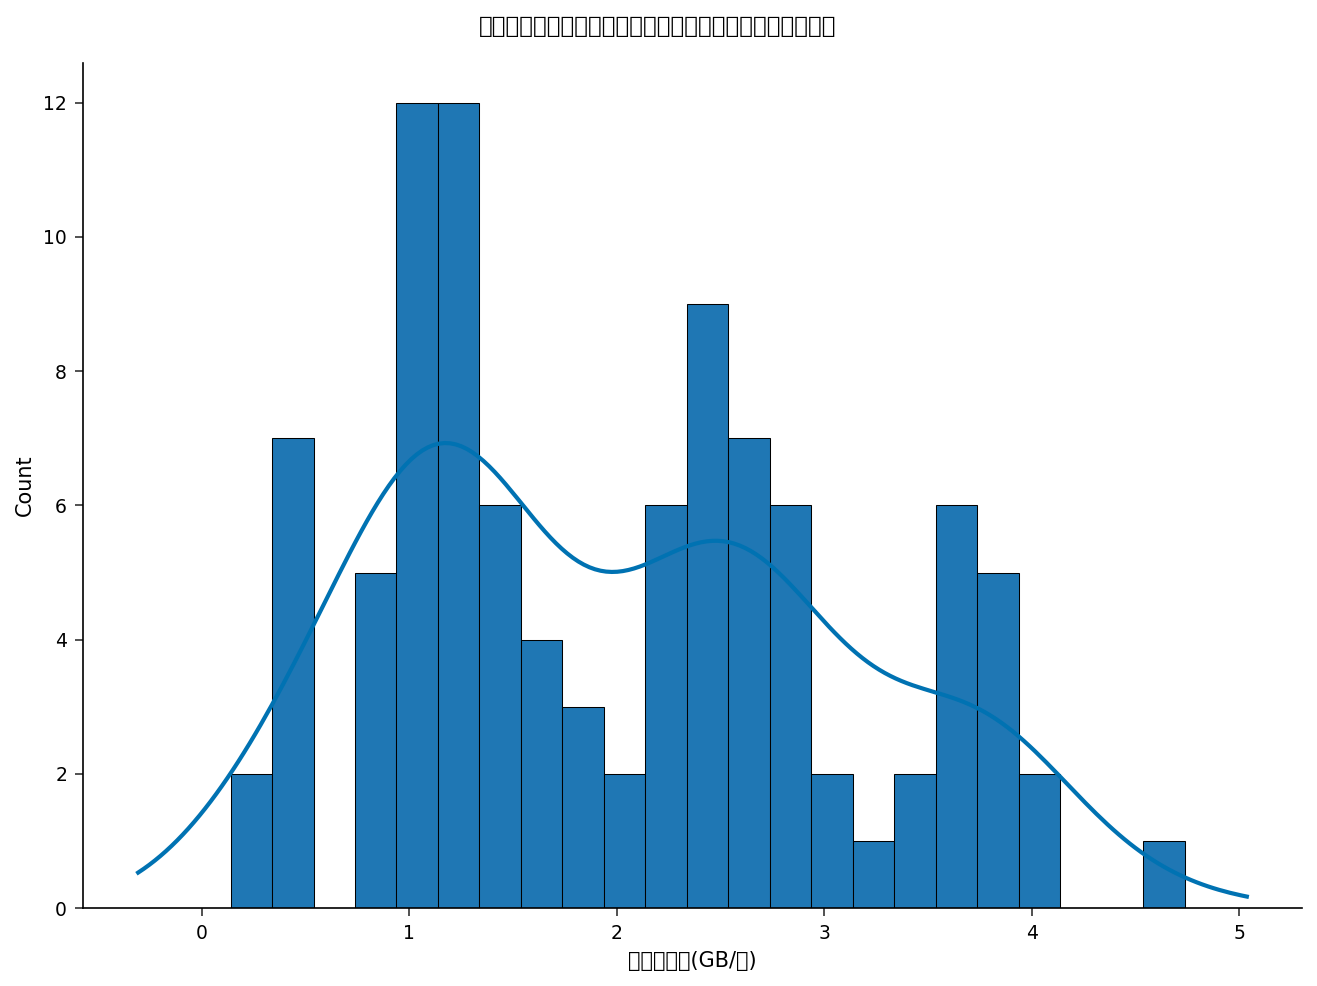

In [2]:
処理 平均 データ=subs n mean std MIN p50 MAX maxdec=2;
   変数 data_gb log_gb tenure_months;
   見出 data_gb='データ利用量(GB)' log_gb='ログ利用量(log GB)' tenure_months='契約期間(月数)';
実行;

処理 SGPLOT データ=subs;
   表題 "月間データ利用量は見えないセグメントの混合分布である";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS 見出="ログ利用量(GB/月)";
実行;
表題;


## ステップ2 — セグメントはいくつか？2・3・4クラスタ解を比較する

ティア数を3と決め打ちにするのではなく、データに語らせる。FASTCLUSは**決定係数（Overall R-Squared）**（クラスタ平均で説明される全分散の割合）と**疑似F統計量**を各解について報告する。`log_gb`に対して`MAXCLUSTERS=`2、3、4を当てはめ、各実行からこれらの基準を読み取る。

- `MAXCLUSTERS=`はクラスタ数*k*を設定する。
- `MAXITER=`はk平均法の再割り当てパス数の上限を設定する。
- `OUT=`はスコア済みデータセットを書き出す（ステップ3～5で使用）。


In [3]:
表題 "2セグメント解";
処理 FASTCLUS データ=subs maxclusters=2 MAXITER=50 out=c2;
   変数 log_gb;
実行;

表題 "3セグメント解";
処理 FASTCLUS データ=subs maxclusters=3 MAXITER=50 out=c3;
   変数 log_gb;
実行;

表題 "4セグメント解";
処理 FASTCLUS データ=subs maxclusters=4 MAXITER=50 out=c4;
   変数 log_gb;
実行;
表題;


                                                        2セグメント解                                                         


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to 2セグメント解.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to 3セグメント解.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to 4セグメント解.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


3つの実行を並べて読むと：**決定係数（Overall R-Squared）**は2クラスタの**0.753**から3クラスタでは**0.899**へと、3つ目のティアが解決されることで大きく+0.146上昇し、4クラスタではわずか**0.941**にしか伸びない。4クラスタ解がこのわずかな上乗せを得ているのは*ライトティアを2つに分割している*からであり（その2つの最小のセントロイドはどちらも仕込んだライトの範囲に収まっている）、真に新しい顧客タイプを見つけているわけではない。**疑似F統計量**も同じ物語を語っている：最大の構造的改善は3クラスタへの移行時に起きている（F = 299 → 431）。3セグメントが誠実な停止点であり、次に採用するモデルである。


## ステップ3 — 3セグメントモデルを当てはめ、各セグメントを特徴付ける

`MAXCLUSTERS=3`で再フィットし、スコア済みの行を`scored`に書き出す。`OUT=`データセットは入力の全列——元の利用量、契約期間、ホールドアウトした`segment_true`を含む——に加えて新しい`CLUSTER`列と`DISTANCE`列を自動的に運ぶため、別途コピーする手順は不要である。FASTCLUSは**クラスタサマリー**（セグメントごとのサイズとクラスタ内ばらつき）と、クラスタリングに使ったスケール（`log_gb`）での**クラスタ平均**を出力する。


In [4]:
処理 FASTCLUS データ=subs maxclusters=3 MAXITER=50 out=scored;
   変数 log_gb;
実行;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


ログスケールでの3つのクラスタ平均は**1.05**、**2.51**、**3.77**である。元のGBスケールに戻すとおよそ**exp(1.05) ≈ 2.9GB**、**exp(2.51) ≈ 12.3GB**、**exp(3.77) ≈ 43GB**——ライト、ミディアム、ヘビーの各ティアに対応する。クラスタサマリーではそれぞれ**49**、**34**、**17**人と算出されており、仕込んだおよそ50/35/15の構成比を追跡できている。次のステップでは同じセグメントを実際のGB単位で読み直す。


## ステップ4 — セグメントをスコアリングし、ビジネス用語で特徴付ける

`OUT=scored`データセットは各加入者の`CLUSTER`（ハードなセグメントラベル）と`DISTANCE`（ログスケールでのクラスタセントロイドからのユークリッド距離——小さいほど確信度の高い中心的な割り当てを意味する）を運ぶ。発見されたセグメントを実際のGB利用量と契約期間で要約し、いくつかのスコア済みの行を一覧表示する。


In [5]:
処理 平均 データ=scored n mean std MIN MAX maxdec=2;
   分類 cluster;
   変数 data_gb tenure_months distance;
   見出 cluster='クラスタ' data_gb='データ利用量(GB)' tenure_months='契約期間(月数)' distance='セントロイドまでの距離';
実行;

処理 印刷 データ=scored(obs=8) noobs 見出;
   変数 subscriber_id data_gb log_gb segment_true cluster distance;
   見出 subscriber_id='加入者ID' data_gb='データ利用量(GB)' log_gb='ログ利用量(log GB)'
         segment_true='真のセグメント' cluster='クラスタ' distance='セントロイドまでの距離';
実行;


                                                  The MEANS Procedure

                                   Analysis Variable : data_gb データ利用量(GB)

        クラスタ                  N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        1                        49           3.07           1.12           1.15           5.83
        2                        34          12.81           3.80           6.57          21.88
        3                        17          45.38          16.44          24.01          98.66
        ---------------------------------------------------------------------------------------

                                 Analysis Variable : tenure_months 契約期間(月数)

        クラスタ                  N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


元のGBスケールでは、3つのセグメントの月間利用量平均はそれぞれ**3.1GB**、**12.8GB**、**45.4GB**——ライトなブラウザーからヘビーなストリーマーまで一桁を超える開きがある。`DISTANCE`列は加入者ごとの確信度の目安を与える：印字された行を見ると、しっかりと割り当てられた顧客（距離が0.01～0.06程度）に加え、セントロイドからやや離れたボーダーラインのライトユーザーも見える——これはまさにリテンションチームが確信度の高いターゲットと要精査ケースを切り分けるために使うシグナルである。


## ステップ5 — 本物のティアを回収できたか、そして構成比は契約期間とともに変化するか

最後に2つの確認を行う。第一に、発見された`CLUSTER`をホールドアウトした`segment_true`とクロス集計し、教師なしフィットが仕込んだティアをどれだけ忠実に回収したかを見る。第二に、発見されたセグメント間で平均契約期間を比較する——生成過程はヘビーユーザーほど契約期間が長くなるよう歪めてあるため、本物のセグメンテーションはそれを反映しているはずである。


                                             発見されたセグメント vs. ホールドアウトした真のティア                                              

                                                   The FREQ Procedure

Table of クラスタ by 真のセグメント

クラスタ         |            ヘビー |          ミディアム |            ライト |           Total
-------------+----------------+----------------+----------------+----------------
1            |              0 |              0 |             49 |              49
-------------+----------------+----------------+----------------+----------------
2            |              1 |             31 |              2 |              34
-------------+----------------+----------------+----------------+----------------
3            |             16 |              1 |              0 |              17
-------------+----------------+----------------+----------------+----------------
Total        |             17 |             32 |             51 |             100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


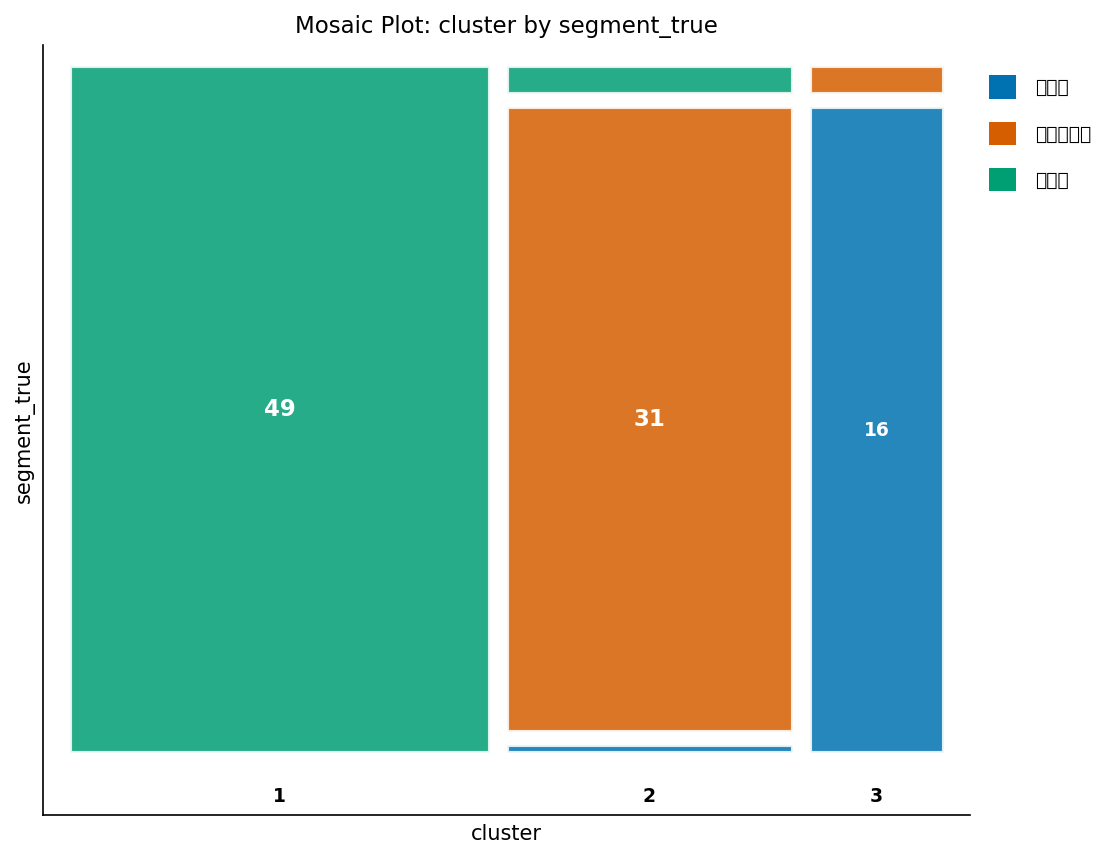

In [6]:
処理 度数 データ=scored;
   表題 "発見されたセグメント vs. ホールドアウトした真のティア";
   TABLES cluster * segment_true / norow nocol nopercent;
   見出 cluster='クラスタ' segment_true='真のセグメント';
実行;
表題;


## 結果の解釈

**FASTCLUSが発見したもの。** ラベルなしの単一の右に歪んだ利用量列から出発し、3クラスタの*k*平均法解はログ利用量の分散の**89.9%**を説明し（決定係数 = 0.899、疑似F = 431）、加入者を**ライト**セグメント（平均3.1GB、n = 49）、**ミディアム**セグメント（平均12.8GB、n = 34）、**ヘビー**セグメント（平均45.4GB、n = 17）に分割した。ホールドアウトした`segment_true`とのクロス集計は、仕込んだ構造をほぼそのまま回収した——**100人中96人**の加入者が、生成時のティアと一致するクラスタに収まった（ライト 49/49、ミディアム 31/34、ヘビー 16/17）。

**なぜログスケールなのか。** データ利用量は厳密に正の値で裾の重い分布であり、`log_gb`をクラスタリングすることでユークリッド距離が意味を持ち続け、セグメント平均がよく分離される。一方、指数による逆変換はGBスケールでの現実的な歪みを再現する。

**なぜこれが業務上重要なのか。** 各加入者はモデルから、ハードなセグメントラベル*と*セントロイドまでの距離スコアの両方を得るため、キャリアは確信度に応じて行動できる——中心的なヘビーユーザーには自信を持ってプレミアムプランをターゲティングし、境界線上の顧客（距離が大きい）には要精査のフラグを立てられる。平均契約期間も発見されたセグメント間で異なっており、ライフサイクルやアップセルのタイミングを図る手がかりになる。

**セグメント数の選び方。** `MAXCLUSTERS=`2、3、4を決定係数と疑似Fで比較することは、*k*を選ぶための透明で再現可能な方法である——3クラスタでの大きな上昇と、4クラスタでの（ライトティアを分割するだけの）見かけ上の上昇にとどまる点が、ここで3を妥当な選択にしている。

**有限混合モデルとの関係。** 有限混合モデル（PROC HPFMM / PROC FMM）であれば、ソフトな事後所属確率と、成分数のための尤度ベースのBICが加わるだろう。これらのプロシジャは本ビルドではまだ数値的に実装されていない。PROC FASTCLUSは、発見・特徴付け・ハードな割り当て・確信度の目安という同じ実用的なセグメンテーションを、今日、完全に数値的で再現可能な出力として提供する。
